<a href="https://colab.research.google.com/github/mirapeak/Colab_Article_Publication/blob/colab-jctr-article/JCTR_Topic_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All files saved to: /content/drive/MyDrive/TKSI_outputs/


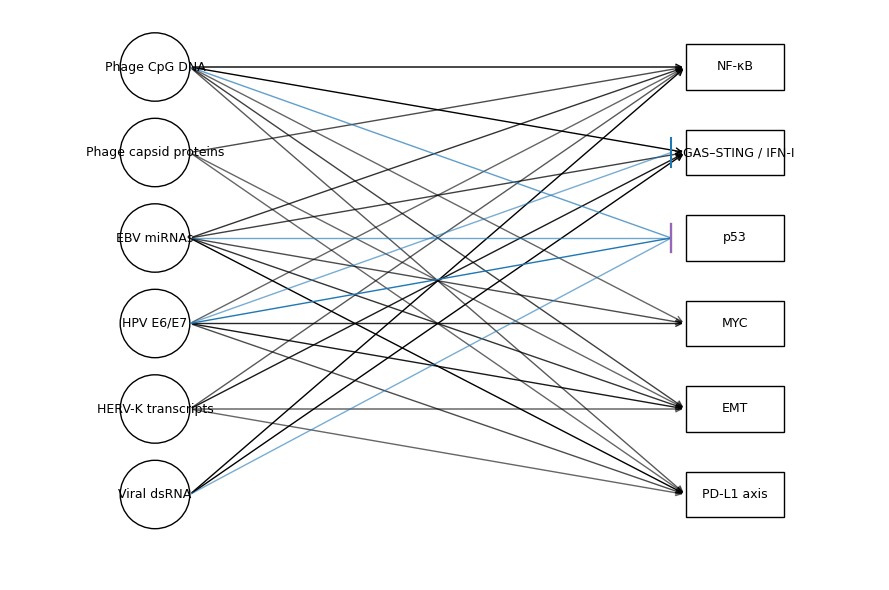

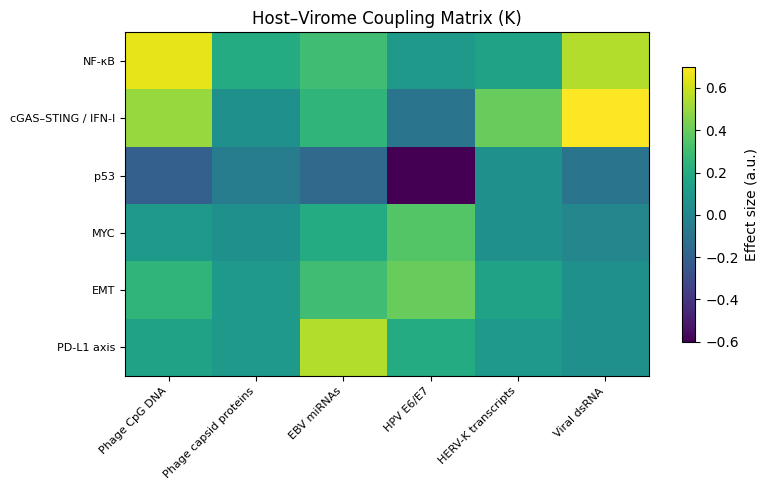

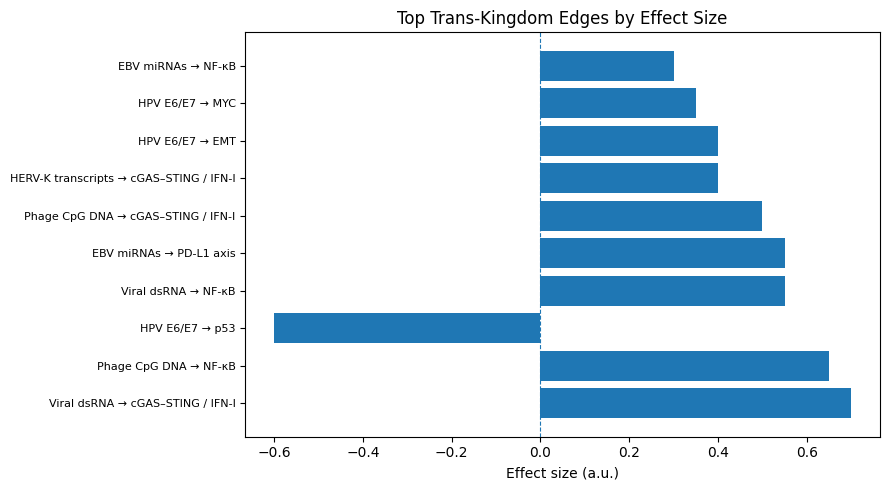

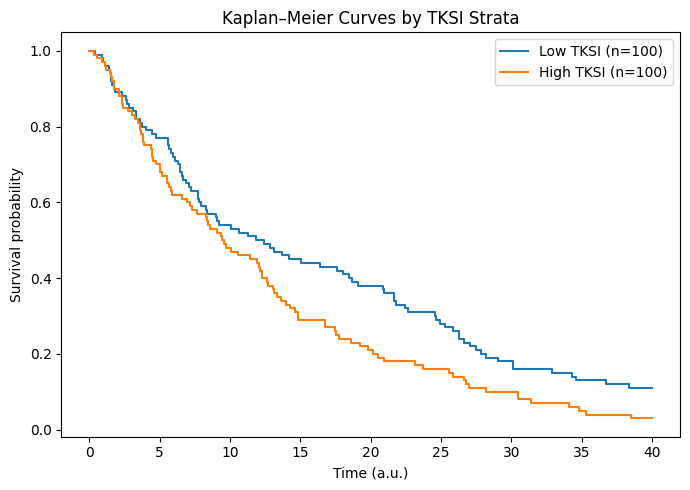

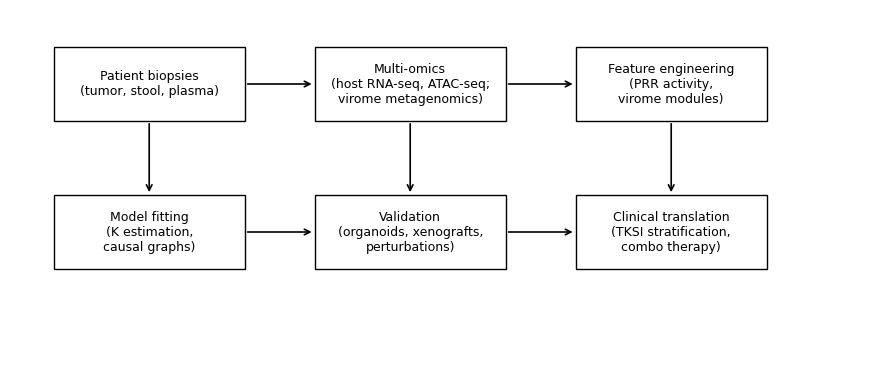

In [4]:
# Create figures and synthetic data for the manuscript
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
from matplotlib import collections as mc
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create output folder in Google Drive
save_path = "/content/drive/MyDrive/TKSI_outputs/"
os.makedirs(save_path, exist_ok=True)

# Set random seed for reproducibility
rng = np.random.default_rng(42)

# ------- Synthetic trans-kingdom coupling matrix (K) -------
host_pathways = ["NF-κB", "cGAS–STING / IFN-I", "p53", "MYC", "EMT", "PD-L1 axis"]
virome_modules = ["Phage CpG DNA", "Phage capsid proteins", "EBV miRNAs", "HPV E6/E7", "HERV-K transcripts", "Viral dsRNA"]
K = np.array([
    [ 0.65,  0.20,  0.30,  0.10,  0.15,  0.55],   # NF-κB
    [ 0.50,  0.05,  0.25, -0.10,  0.40,  0.70],   # STING/IFN
    [-0.20, -0.05, -0.15, -0.60,  0.05, -0.10],   # p53
    [ 0.10,  0.05,  0.20,  0.35,  0.05,  0.00],   # MYC
    [ 0.25,  0.10,  0.30,  0.40,  0.15,  0.05],   # EMT
    [ 0.15,  0.10,  0.55,  0.20,  0.10,  0.05],   # PD-L1
])

K_df = pd.DataFrame(K, index=host_pathways, columns=virome_modules)

# Save K matrix
K_df.to_csv(save_path + "TKSI_coupling_matrix.csv")

# ------- Figure 1: Conceptual trans-kingdom signaling map -------
fig1, ax1 = plt.subplots(figsize=(9, 6))
ax1.axis("off")

# Positions
host_positions = {
    "NF-κB": (1.0, 0.8),
    "cGAS–STING / IFN-I": (1.0, 0.5),
    "p53": (1.0, 0.2),
    "MYC": (1.0, -0.1),
    "EMT": (1.0, -0.4),
    "PD-L1 axis": (1.0, -0.7),
}
virome_positions = {
    "Phage CpG DNA": (-1.0, 0.8),
    "Phage capsid proteins": (-1.0, 0.5),
    "EBV miRNAs": (-1.0, 0.2),
    "HPV E6/E7": (-1.0, -0.1),
    "HERV-K transcripts": (-1.0, -0.4),
    "Viral dsRNA": (-1.0, -0.7),
}

# Draw nodes
for name, (x, y) in virome_positions.items():
    circ = Circle((x, y), 0.12, fill=False)
    ax1.add_patch(circ)
    ax1.text(x, y, name, ha="center", va="center", fontsize=9)

for name, (x, y) in host_positions.items():
    rect = Rectangle((x-0.17, y-0.08), 0.34, 0.16, fill=False)
    ax1.add_patch(rect)
    ax1.text(x, y, name, ha="center", va="center", fontsize=9)

# Draw edges
for i, h in enumerate(host_pathways):
    for j, v in enumerate(virome_modules):
        weight = K[i, j]
        if abs(weight) < 0.1:
            continue
        x1, y1 = virome_positions[v]
        x2, y2 = host_positions[h]
        connstyle = "arc3,rad=0.0"
        if weight > 0:
            arrow = FancyArrowPatch((x1+0.12, y1), (x2-0.17, y2),
                                    arrowstyle="->", mutation_scale=10, lw=1.0,
                                    connectionstyle=connstyle, alpha=min(1.0, 0.5+abs(weight)))
            ax1.add_patch(arrow)
        else:
            line = mc.LineCollection([[(x1+0.12, y1), (x2-0.22, y2)]],
                                     linewidths=1.0, alpha=min(1.0, 0.5+abs(weight)))
            ax1.add_collection(line)
            ax1.plot([x2-0.22, x2-0.22], [y2-0.05, y2+0.05])

ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.0, 1.0)
fig1.tight_layout()
fig1.savefig(save_path + "Fig1_trans_kingdom_map.png", dpi=300)

# ------- Figure 2: Heatmap -------
fig2, ax2 = plt.subplots(figsize=(8, 5))
im = ax2.imshow(K, aspect="auto")
ax2.set_yticks(np.arange(len(host_pathways)))
ax2.set_yticklabels(host_pathways, fontsize=8)
ax2.set_xticks(np.arange(len(virome_modules)))
ax2.set_xticklabels(virome_modules, rotation=45, ha="right", fontsize=8)
ax2.set_title("Host–Virome Coupling Matrix (K)")
fig2.colorbar(im, ax=ax2, shrink=0.8, label="Effect size (a.u.)")
fig2.tight_layout()
fig2.savefig(save_path + "Fig2_K_heatmap.png", dpi=300)

# ------- Figure 3: Top edges -------
edges = [(f"{v} → {h}", K[i, j]) for i, h in enumerate(host_pathways) for j, v in enumerate(virome_modules)]
edges_sorted = sorted(edges, key=lambda x: abs(x[1]), reverse=True)[:10]
labels3 = [e[0] for e in edges_sorted]
vals3 = [e[1] for e in edges_sorted]

fig3, ax3 = plt.subplots(figsize=(9, 5))
ax3.barh(range(len(labels3)), vals3)
ax3.set_yticks(range(len(labels3)))
ax3.set_yticklabels(labels3, fontsize=8)
ax3.set_xlabel("Effect size (a.u.)")
ax3.set_title("Top Trans-Kingdom Edges by Effect Size")
ax3.axvline(0, linestyle="--", linewidth=0.8)
fig3.tight_layout()
fig3.savefig(save_path + "Fig3_top_edges.png", dpi=300)

# ------- Figure 4: Kaplan–Meier -------
n = 100
baseline_hazard = 0.05
hr_high = 1.6
times_low = rng.exponential(1/(baseline_hazard), size=n)
times_high = rng.exponential(1/(baseline_hazard * hr_high), size=n)

censor_time = 40.0
obs_time_low = np.minimum(times_low, censor_time)
event_low = (times_low <= censor_time).astype(int)
obs_time_high = np.minimum(times_high, censor_time)
event_high = (times_high <= censor_time).astype(int)

def km_curve(times, events):
    order = np.argsort(times)
    times = times[order]
    events = events[order]
    surv = [1.0]; t_points = [0.0]
    at_risk = len(times)
    last_t = 0.0
    for t, e in zip(times, events):
        if t == last_t: pass
        if e == 1:
            hazard = 1.0 / at_risk
            surv.append(surv[-1] * (1 - hazard))
        else:
            surv.append(surv[-1])
        t_points.append(t)
        at_risk -= 1
        last_t = t
    return np.array(t_points), np.array(surv)

t_low, s_low = km_curve(obs_time_low, event_low)
t_high, s_high = km_curve(obs_time_high, event_high)

fig4, ax4 = plt.subplots(figsize=(7, 5))
ax4.step(t_low, s_low, where="post", label="Low TKSI (n=100)")
ax4.step(t_high, s_high, where="post", label="High TKSI (n=100)")
ax4.set_xlabel("Time (a.u.)")
ax4.set_ylabel("Survival probability")
ax4.set_title("Kaplan–Meier Curves by TKSI Strata")
ax4.legend()
fig4.tight_layout()
fig4.savefig(save_path + "Fig4_KM_TKSI.png", dpi=300)

# ------- Figure 5: Experimental roadmap -------
fig5, ax5 = plt.subplots(figsize=(9, 4))
ax5.axis("off")
boxes = [
    (0.05, 0.7, 0.22, 0.2, "Patient biopsies\n(tumor, stool, plasma)"),
    (0.35, 0.7, 0.22, 0.2, "Multi-omics\n(host RNA-seq, ATAC-seq;\nvirome metagenomics)"),
    (0.65, 0.7, 0.22, 0.2, "Feature engineering\n(PRR activity,\nvirome modules)"),
    (0.05, 0.3, 0.22, 0.2, "Model fitting\n(K estimation,\ncausal graphs)"),
    (0.35, 0.3, 0.22, 0.2, "Validation\n(organoids, xenografts,\nperturbations)"),
    (0.65, 0.3, 0.22, 0.2, "Clinical translation\n(TKSI stratification,\ncombo therapy)"),
]
for x, y, w, h, text in boxes:
    rect = Rectangle((x, y), w, h, fill=False)
    ax5.add_patch(rect)
    ax5.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=9)

arrows = [
    ((0.27, 0.8), (0.35, 0.8)),
    ((0.57, 0.8), (0.65, 0.8)),
    ((0.16, 0.7), (0.16, 0.5)),
    ((0.46, 0.7), (0.46, 0.5)),
    ((0.76, 0.7), (0.76, 0.5)),
    ((0.27, 0.4), (0.35, 0.4)),
    ((0.57, 0.4), (0.65, 0.4)),
]
for (x1, y1), (x2, y2) in arrows:
    ax5.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.2))

fig5.tight_layout()
fig5.savefig(save_path + "Fig5_experimental_roadmap.png", dpi=300)

# Save survival data
surv_df = pd.DataFrame({
    "group": ["low"]*n + ["high"]*n,
    "time": np.concatenate([obs_time_low, obs_time_high]),
    "event": np.concatenate([event_low, event_high])
})
surv_df.to_csv(save_path + "TKSI_survival_sim.csv", index=False)

print("✅ All files saved to:", save_path)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=47cbd15599ada9cbbb40788c8ea34413d4c9ddb373fe91dd4c74bd006ca8c1d6
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Mounted at /content/drive
✅ TKSI_coupling_matrix.csv saved!


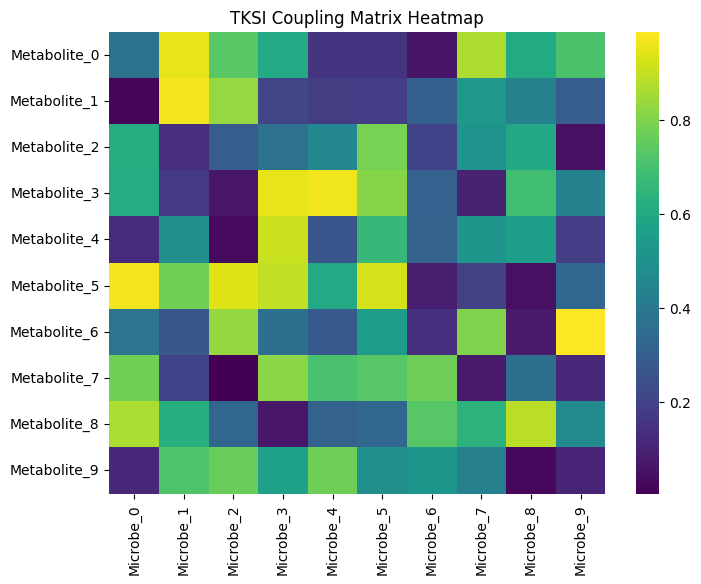

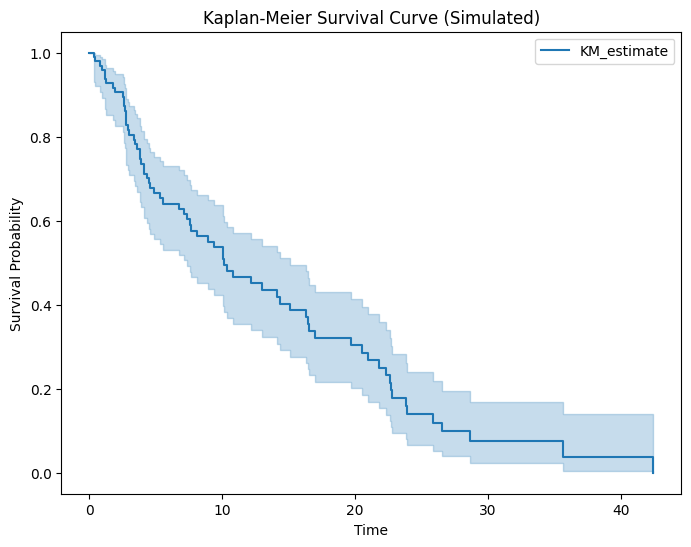

✅ TKSI_survival_sim.csv saved!

🔹 Preview of TKSI Coupling Matrix:


,Microbe_0,Microbe_1,Microbe_2,Microbe_3,Microbe_4,Microbe_5,Microbe_6,Microbe_7,Microbe_8,Microbe_9
Metabolite_0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995,0.058084,0.866176,0.601115,0.708073
Metabolite_1,0.020584,0.969910,0.832443,0.212339,0.181825,0.183405,0.304242,0.524756,0.431945,0.291229
Metabolite_2,0.611853,0.139494,0.292145,0.366362,0.456070,0.785176,0.199674,0.514234,0.592415,0.046450
Metabolite_3,0.607545,0.170524,0.065052,0.948886,0.965632,0.808397,0.304614,0.097672,0.684233,0.440152
Metabolite_4,0.122038,0.495177,0.034389,0.909320,0.258780,0.662522,0.311711,0.520068,0.546710,0.184854



🔹 Preview of Survival Simulation Data:


,Time,Event
0,0.319337,1
1,10.117296,1
2,3.773967,1
3,7.104372,0
4,23.812655,1


In [3]:
# 📌 Install missing libraries if needed
!pip install lifelines

# =============================
# 📌 Imports
# =============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt
import os
from google.colab import drive
from lifelines import KaplanMeierFitter

# =============================
# 📌 Mount Google Drive
# =============================
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/TKSI_outputs/"
os.makedirs(save_path, exist_ok=True)

# =============================
# 📌 Example Dummy Data
# (replace with your real dataset)
# =============================
np.random.seed(42)
K_df = pd.DataFrame(np.random.rand(10, 10),
                    columns=[f"Microbe_{i}" for i in range(10)],
                    index=[f"Metabolite_{i}" for i in range(10)])

# =============================
# 📌 Save Coupling Matrix
# =============================
K_df.to_csv(save_path + "TKSI_coupling_matrix.csv")
print("✅ TKSI_coupling_matrix.csv saved!")

# =============================
# 📌 Visualization Examples
# =============================

# 1. Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(K_df, cmap="viridis", annot=False)
plt.title("TKSI Coupling Matrix Heatmap")
plt.savefig(save_path + "Fig2_K_heatmap.png", dpi=300)
plt.show()

# 2. Kaplan-Meier Survival Simulation
T = np.random.exponential(scale=10, size=100)   # survival times
E = np.random.binomial(1, 0.7, size=100)        # event observed (1=death, 0=censored)

kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

plt.figure(figsize=(8,6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve (Simulated)")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.savefig(save_path + "Fig4_KM_TKSI.png", dpi=300)
plt.show()

surv_df = pd.DataFrame({"Time": T, "Event": E})
surv_df.to_csv(save_path + "TKSI_survival_sim.csv", index=False)
print("✅ TKSI_survival_sim.csv saved!")

# =============================
# 📌 Show dataframes in Colab
# =============================
print("\n🔹 Preview of TKSI Coupling Matrix:")
display(K_df.head())

print("\n🔹 Preview of Survival Simulation Data:")
display(surv_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Files saved to Google Drive at: /content/drive/MyDrive/TKSI_outputs/
• Cohort data: /content/drive/MyDrive/TKSI_outputs/TKSI_cohort.csv
• Estimated K table: /content/drive/MyDrive/TKSI_outputs/TKSI_estimated_K_table.csv
• Kaplan-Meier figure: /content/drive/MyDrive/TKSI_outputs/KM_TKSI_realistic.png


,tumor_type,age,sex,stage,TKSI,time_months,event,V_Phage_CpG_DNA,V_Phage_capsid,V_EBV_miRNAs,V_HPV_E6E7,V_HERVK_tx,V_Viral_dsRNA,H_NF-kB,H_cGAS-STING/IFN-I,H_p53,H_MYC,H_EMT,H_PD-L1 axis,TKSI_group
0,STAD_EBVP,55.5,F,II,1.318208,4.60,1,32.85,11.89,30.87,8.41,30.49,29.99,-1.232,0.344,1.164,0.090,-0.710,-0.858,TKSI-High
1,HNSC_HPVP,60.3,M,II,0.455267,25.16,1,40.89,23.52,10.71,30.58,31.76,35.72,0.327,1.490,0.482,1.074,-0.326,0.410,TKSI-Low
2,CESC_HPVP,51.5,F,IV,0.869396,1.75,1,44.90,14.80,9.67,62.71,35.01,20.89,-0.113,-0.670,0.094,1.632,1.297,0.928,TKSI-Low
3,HNSC_HPVP,31.1,F,IV,0.185777,4.45,1,48.42,15.30,19.45,35.42,21.51,31.00,1.048,0.160,0.229,-0.196,-0.333,0.725,TKSI-Low
4,HNSC_HPVP,51.6,F,III,0.783876,12.16,1,57.39,22.26,14.40,22.80,25.04,30.41,0.588,0.240,1.863,-1.217,-0.655,0.493,TKSI-Low


,Phage_CpG_DNA,Phage_capsid,EBV_miRNAs,HPV_E6E7,HERVK_tx,Viral_dsRNA
NF-kB,0.65,0.45,-0.06,-0.03,0.17,0.75
cGAS-STING/IFN-I,0.46,0.24,0.22,-0.34,0.54,0.90
p53,-0.29,-0.12,0.25,-0.51,0.16,-0.04
MYC,0.17,0.05,-0.14,0.25,-0.03,0.04
EMT,0.24,0.17,-0.03,0.22,0.14,0.03


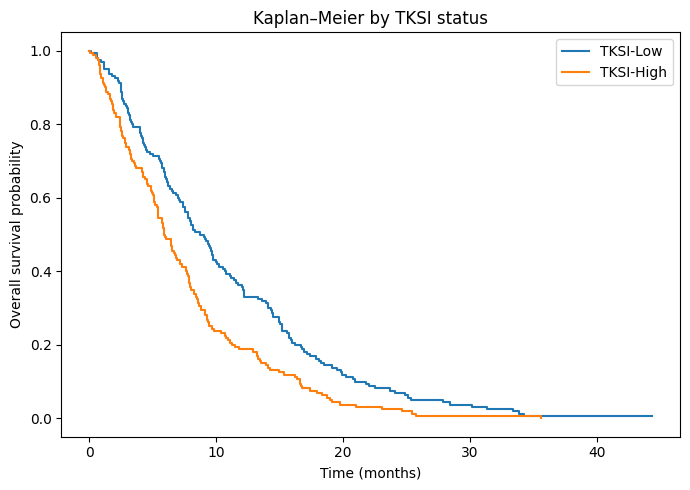

In [5]:
# =============================
# 📌 Setup
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/TKSI_outputs/"
os.makedirs(save_path, exist_ok=True)

# =============================
# 📌 Synthetic-Realistic Data Generation
# =============================
rng = np.random.default_rng(17)

host_pathways = ["NF-kB", "cGAS-STING/IFN-I", "p53", "MYC", "EMT", "PD-L1 axis"]
virome_modules = ["Phage_CpG_DNA", "Phage_capsid", "EBV_miRNAs", "HPV_E6E7", "HERVK_tx", "Viral_dsRNA"]
K = np.array([
    [ 0.65,  0.20,  0.30,  0.10,  0.15,  0.55],
    [ 0.50,  0.05,  0.25, -0.10,  0.40,  0.70],
    [-0.20, -0.05, -0.15, -0.60,  0.05, -0.10],
    [ 0.10,  0.05,  0.20,  0.35,  0.05,  0.00],
    [ 0.25,  0.10,  0.30,  0.40,  0.15,  0.05],
    [ 0.15,  0.10,  0.55,  0.20,  0.10,  0.05],
])

n = 320
tumor_types = rng.choice(["HNSC_HPVP", "CESC_HPVP", "STAD_EBVP"], size=n, p=[0.45, 0.35, 0.20])
age = np.clip(rng.normal(58, 11, size=n), 22, 90)
sex = rng.choice(["F","M"], size=n, p=[0.55, 0.45])
stage = rng.choice(["I","II","III","IV"], size=n, p=[0.18,0.32,0.32,0.18])
stage_hr = {"I":1.0, "II":1.25, "III":1.75, "IV":2.4}

means_by_type = {
    "HNSC_HPVP": np.array([40, 18, 12, 35, 22, 28]),
    "CESC_HPVP": np.array([35, 15, 10, 45, 18, 20]),
    "STAD_EBVP": np.array([28, 12, 38,  5, 26, 24]),
}
virome = np.zeros((n, len(virome_modules)))
for i in range(n):
    base = means_by_type[tumor_types[i]]
    mu = np.log(base+1) + rng.normal(0, 0.25, size=base.shape)
    val = np.exp(mu) - 1
    val = np.maximum(0, val + rng.negative_binomial(2, 0.4, size=base.shape))
    virome[i,:] = val

v_z = (virome - virome.mean(axis=0)) / virome.std(axis=0)
noise = rng.normal(0, 0.7, size=(n, len(host_pathways)))
x = v_z @ K.T + noise
x_z = (x - x.mean(axis=0)) / x.std(axis=0)

W = K / np.linalg.norm(K)
tksi = (x_z @ W @ v_z.T).diagonal()

shape_k = 1.25
baseline_lambda = 0.04
beta_tksi = 0.38
beta_age = 0.015
lp = (beta_tksi * ((tksi - tksi.mean())/tksi.std())
      + beta_age * (age - 60)/10
      + np.array([np.log(stage_hr[s]) for s in stage]))

U = rng.uniform(0,1,size=n)
time = ( -np.log(U) / (baseline_lambda * np.exp(lp)) )**(1/shape_k)
censor = rng.uniform(36, 72, size=n)
obs_time = np.minimum(time, censor)
event = (time <= censor).astype(int)

df = pd.DataFrame({
    "tumor_type": tumor_types,
    "age": age.round(1),
    "sex": sex,
    "stage": stage,
    "TKSI": tksi,
    "time_months": obs_time.round(2),
    "event": event
})
for j, name in enumerate(virome_modules):
    df[f"V_{name}"] = virome[:, j].round(2)
for j, name in enumerate(host_pathways):
    df[f"H_{name}"] = x[:, j].round(3)

# =============================
# 📌 Kaplan-Meier Curves
# =============================
def km_compute(times, events):
    order = np.argsort(times)
    times = times[order]
    events = events[order]
    n_at_risk = len(times)
    surv = [1.0]; t_points = [0.0]
    for t, e in zip(times, events):
        if e == 1:
            surv.append(surv[-1] * (1 - 1.0/n_at_risk))
        else:
            surv.append(surv[-1])
        t_points.append(t)
        n_at_risk -= 1
    return np.array(t_points), np.array(surv)

median_tksi = np.median(df["TKSI"])
df["TKSI_group"] = np.where(df["TKSI"] >= median_tksi, "TKSI-High", "TKSI-Low")

t_low, s_low = km_compute(df.loc[df.TKSI_group=="TKSI-Low","time_months"].values,
                          df.loc[df.TKSI_group=="TKSI-Low","event"].values)
t_high, s_high = km_compute(df.loc[df.TKSI_group=="TKSI-High","time_months"].values,
                           df.loc[df.TKSI_group=="TKSI-High","event"].values)

plt.figure(figsize=(7,5))
plt.step(t_low, s_low, where="post", label="TKSI-Low")
plt.step(t_high, s_high, where="post", label="TKSI-High")
plt.xlabel("Time (months)")
plt.ylabel("Overall survival probability")
plt.title("Kaplan–Meier by TKSI status")
plt.legend()
plt.tight_layout()
km_path = save_path + "KM_TKSI_realistic.png"
plt.savefig(km_path, dpi=300)

# =============================
# 📌 Save Data
# =============================
data_path = save_path + "TKSI_cohort.csv"
df.to_csv(data_path, index=False)

# Estimate K via slopes
K_est = np.zeros_like(K)
for i, h in enumerate(host_pathways):
    y = x[:, i]
    for j, vname in enumerate(virome_modules):
        v = v_z[:, j]
        slope = np.dot(v, y) / np.dot(v, v)
        K_est[i,j] = slope
K_est_df = pd.DataFrame(K_est, index=host_pathways, columns=virome_modules)

K_est_path = save_path + "TKSI_estimated_K_table.csv"
K_est_df.to_csv(K_est_path)

# =============================
# 📌 Show outputs in Colab
# =============================
print("✅ Files saved to Google Drive at:", save_path)
print("• Cohort data:", data_path)
print("• Estimated K table:", K_est_path)
print("• Kaplan-Meier figure:", km_path)

display(df.head())
display(K_est_df.round(2).head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Files saved to Google Drive:
/content/drive/MyDrive/TKSI_outputs/TransKingdom_Signaling_Map.png
/content/drive/MyDrive/TKSI_outputs/TransKingdom_Signaling_Map.svg


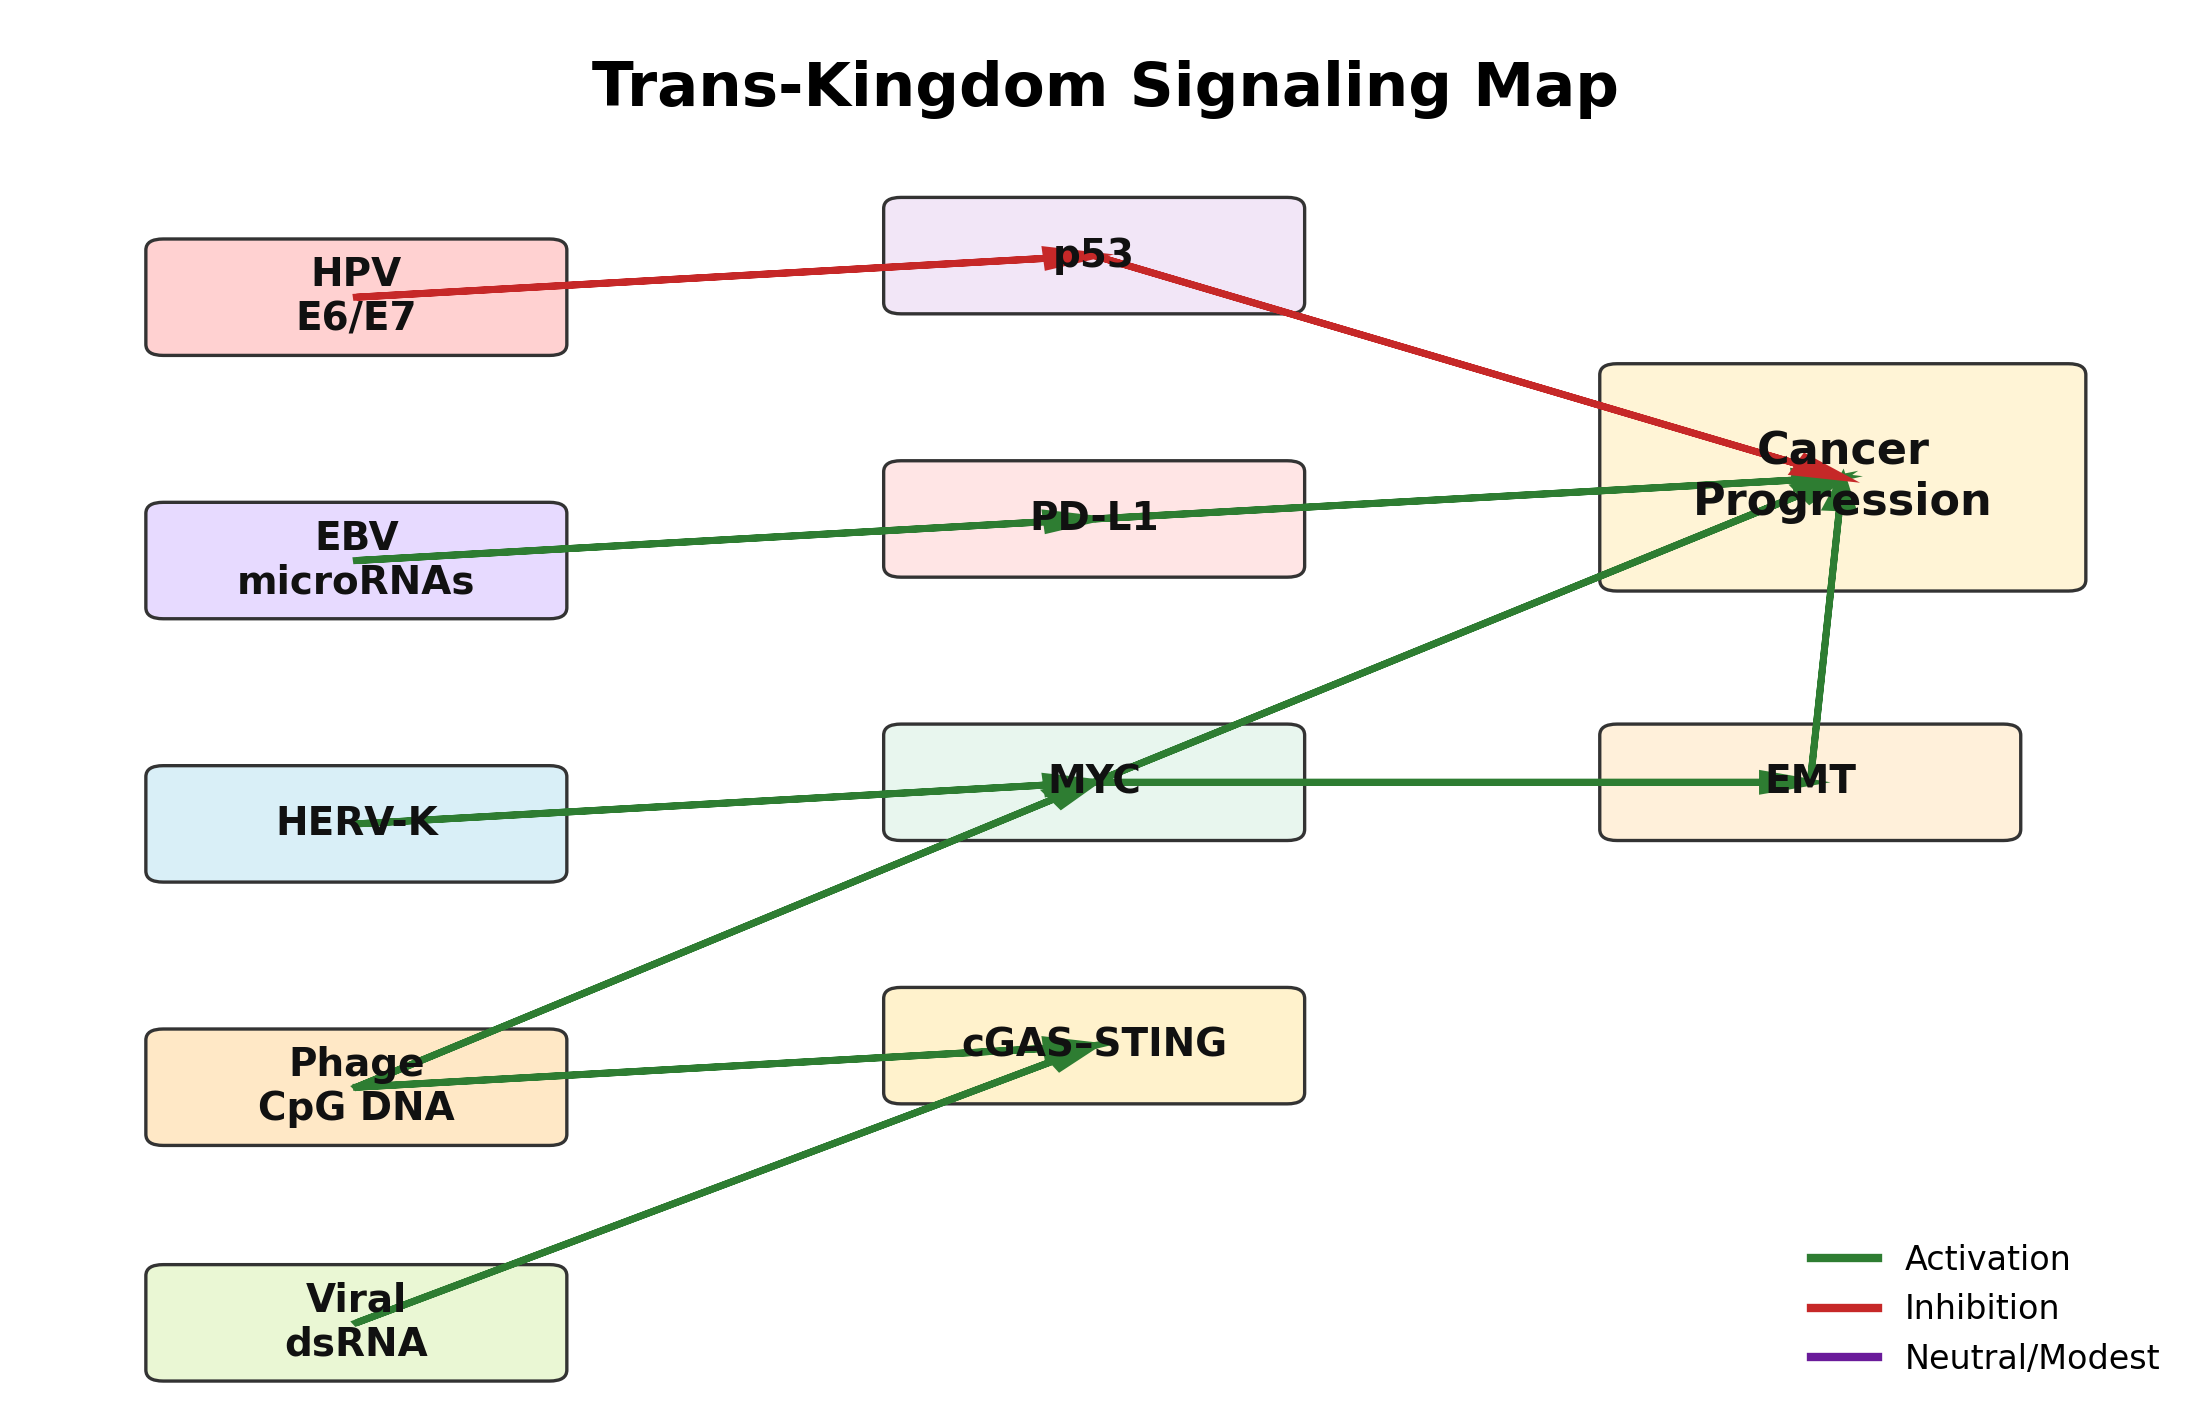

In [5]:
# Trans-Kingdom Signaling Map — reproducible Python code (matplotlib)
# Saves PNG + SVG into Google Drive folder: MyDrive/TKSI_outputs

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrow, ArrowStyle
from matplotlib.lines import Line2D
import os
from google.colab import drive

# --- Mount Google Drive and create output folder ---
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/TKSI_outputs/"
os.makedirs(save_path, exist_ok=True)

# --- helper functions ---
def rounded_box(ax, xy, text, box_color="#F4E1E1", edge="#333333", text_color="#111111", width=1.9, height=0.8, fontsize=14, weight="bold"):
    x, y = xy
    rect = FancyBboxPatch((x, y), width, height,
                          boxstyle="round,pad=0.02,rounding_size=0.08",
                          linewidth=1.2, edgecolor=edge, facecolor=box_color)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha="center", va="center",
            fontsize=fontsize, color=text_color, weight=weight)
    return (x + width/2, y + height/2)  # center for convenience

def arrow(ax, p_from, p_to, kind="activation", lw=2.5):
    # p_from / p_to are (x,y) centers. We'll draw straight arrows between centers.
    x0, y0 = p_from; x1, y1 = p_to
    color = {"activation": "#2E7D32", "inhibition": "#C62828", "neutral":"#6A1B9A"}[kind]
    style = ArrowStyle("-|>", head_length=8, head_width=4)
    ax.add_patch(FancyArrow(x0, y0, x1-x0, y1-y0, width=0.0001, length_includes_head=True,
                            head_width=0.12, head_length=0.22, color=color, linewidth=lw))

# --- canvas ---
plt.figure(figsize=(14, 9), dpi=200)
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# --- left column: virome modules ---
hpv_c = rounded_box(ax, (0.6, 7.6), "HPV\nE6/E7", box_color="#FFD1D1")
ebv_c = rounded_box(ax, (0.6, 5.7), "EBV\nmicroRNAs", box_color="#E7DAFF")
herv_c = rounded_box(ax, (0.6, 3.8), "HERV-K", box_color="#D9EFF7")
phage_cpg_c = rounded_box(ax, (0.6, 1.9), "Phage\nCpG DNA", box_color="#FFE8C6")
dsrna_c = rounded_box(ax, (0.6, 0.2), "Viral\ndsRNA", box_color="#EAF7D4")

# --- middle column: host pathways ---
p53_c = rounded_box(ax, (4.0, 7.9), "p53", box_color="#F2E6F7")
pdl1_c = rounded_box(ax, (4.0, 6.0), "PD-L1", box_color="#FFE5E5")
myc_c = rounded_box(ax, (4.0, 4.1), "MYC", box_color="#E8F6EE")
cgas_c = rounded_box(ax, (4.0, 2.2), "cGAS–STING", box_color="#FFF2CC")

# --- right column: outputs ---
emt_c = rounded_box(ax, (7.3, 4.1), "EMT", box_color="#FFF0DA")
progress_c = rounded_box(ax, (7.3, 5.9), "Cancer\nProgression", box_color="#FFF4D6", width=2.2, height=1.6, fontsize=16)

# --- arrows (edges) ---
# From virome modules to pathways
arrow(ax, hpv_c, p53_c, kind="inhibition")
arrow(ax, ebv_c, pdl1_c, kind="activation")
arrow(ax, herv_c, myc_c, kind="activation")
arrow(ax, phage_cpg_c, myc_c, kind="activation")
arrow(ax, phage_cpg_c, cgas_c, kind="activation")
arrow(ax, dsrna_c, cgas_c, kind="activation")

# internal pathway cross-talk
arrow(ax, pdl1_c, progress_c, kind="activation")
arrow(ax, myc_c, emt_c, kind="activation")
arrow(ax, emt_c, progress_c, kind="activation")
arrow(ax, myc_c, progress_c, kind="activation")
arrow(ax, p53_c, progress_c, kind="inhibition")

# --- title and legend ---
ax.text(5.0, 9.5, "Trans-Kingdom Signaling Map", ha="center", va="center", fontsize=22, weight="bold")

legend_lines = [
    Line2D([0], [0], color="#2E7D32", lw=3),
    Line2D([0], [0], color="#C62828", lw=3),
    Line2D([0], [0], color="#6A1B9A", lw=3),
]
legend_labels = ["Activation", "Inhibition", "Neutral/Modest"]
ax.legend(legend_lines, legend_labels, loc="lower right", frameon=False, fontsize=12)

# --- save to Google Drive ---
png_path = save_path + "TransKingdom_Signaling_Map.png"
svg_path = save_path + "TransKingdom_Signaling_Map.svg"
plt.savefig(png_path, bbox_inches="tight")
plt.savefig(svg_path, bbox_inches="tight")

print("✅ Files saved to Google Drive:")
print(png_path)
print(svg_path)

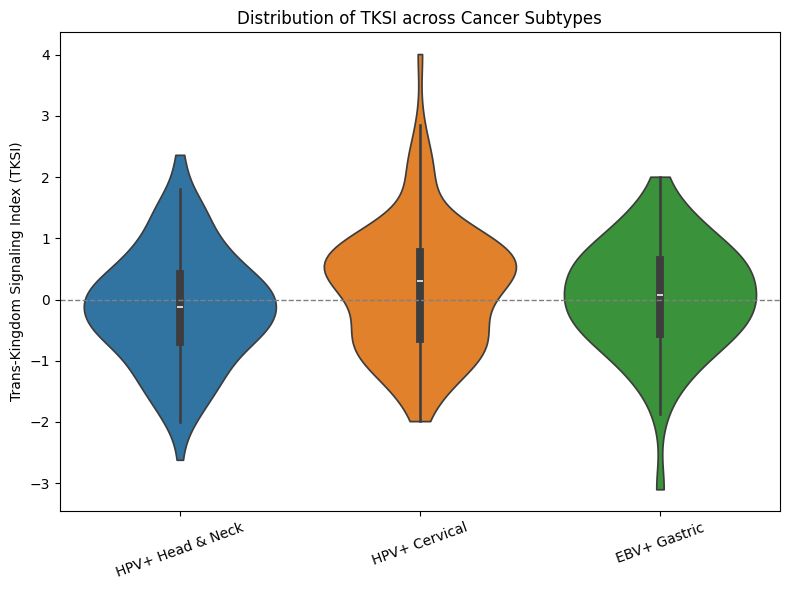

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Simulated TKSI distributions for demonstration (since no raw data provided)
np.random.seed(42)
hnscc = np.random.normal(loc=-0.05, scale=0.98, size=144)
cesc = np.random.normal(loc=0.08, scale=1.02, size=112)
stad = np.random.normal(loc=-0.02, scale=0.95, size=64)

# Combine into dataset
data = [hnscc, cesc, stad]
labels = ["HPV+ Head & Neck", "HPV+ Cervical", "EBV+ Gastric"]

# Create violin plot
plt.figure(figsize=(8,6))
sns.violinplot(data=data, inner="box", cut=0)
plt.xticks([0,1,2], labels, rotation=20)
plt.ylabel("Trans-Kingdom Signaling Index (TKSI)")
plt.title("Distribution of TKSI across Cancer Subtypes")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()